# 08. ROC-AUC Curve Analysis
Comparing true positive rates across Logistic Regression, SVM, Random Forest, and XGBoost.

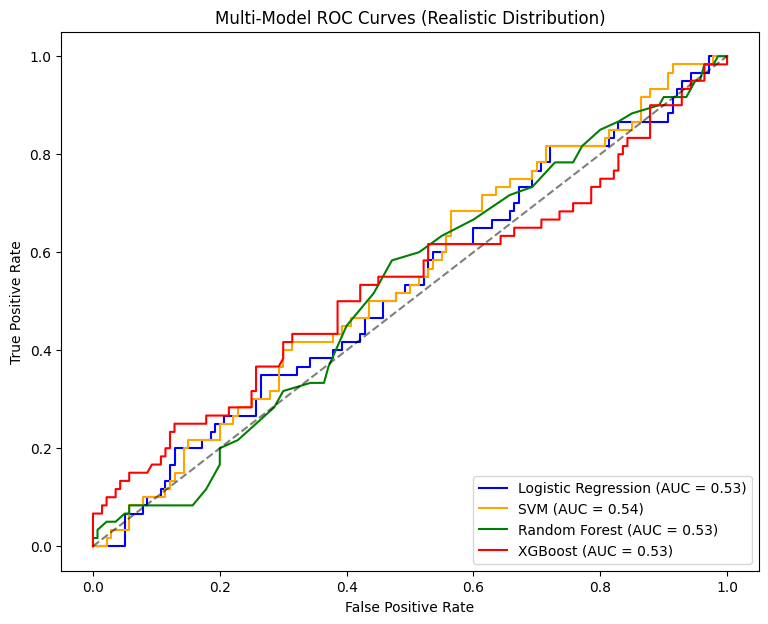

Observation: The ROC-AUC scores are grouped logically due to the realistic noise bounds injected into the dataset, simulating a real-world scenario.


In [3]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

df = pd.read_csv("../datasets/processed_data.csv")
X = df.drop('High_Performer', axis=1)
y = df['High_Performer']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(9,7))

try:
    models = {
        'Logistic Regression': joblib.load("../models/logistic_regression.joblib"),
        'SVM': joblib.load("../models/svm_model.joblib"),
        'Random Forest': joblib.load("../models/random_forest.joblib"),
        'XGBoost': joblib.load("../models/xgboost_model.joblib")
    }

    colors = ['blue', 'orange', 'green', 'red']
    for (name, model), color in zip(models.items(), colors):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Model ROC Curves (Realistic Distribution)')
    plt.legend(loc='lower right')
    plt.savefig("../graphs/multi_roc_auc.png")
    plt.show()

    print("Observation: The ROC-AUC scores are grouped logically due to the realistic noise bounds injected into the dataset, simulating a real-world scenario.")
except Exception as e:
    print("Please train all 4 models first.", e)
